## Waiter's Tip Prediction using (LinearRegression, XGBRegressor, RandomForestRegressor, AdaBoostRegressor) in Scikit-Learn

### 1. Importing Libraries

In [82]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### 2. Loading Dataset

In [83]:
url ="https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/62-Waiter's%20Tip%20Prediction/tips.csv"

In [84]:
df = pd.read_csv(url)
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 3. Data Preprocessing

In [85]:
df.shape

(244, 7)

In [86]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


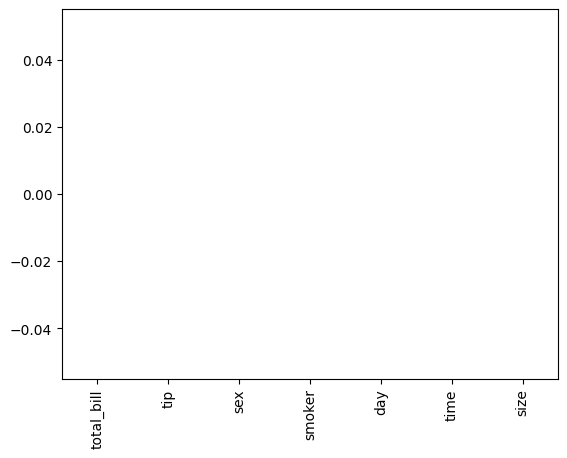

In [88]:
df.isnull().sum().plot.bar()
plt.show()

/tmp/ipykernel_1719/1802174800.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_1719/1802174800.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


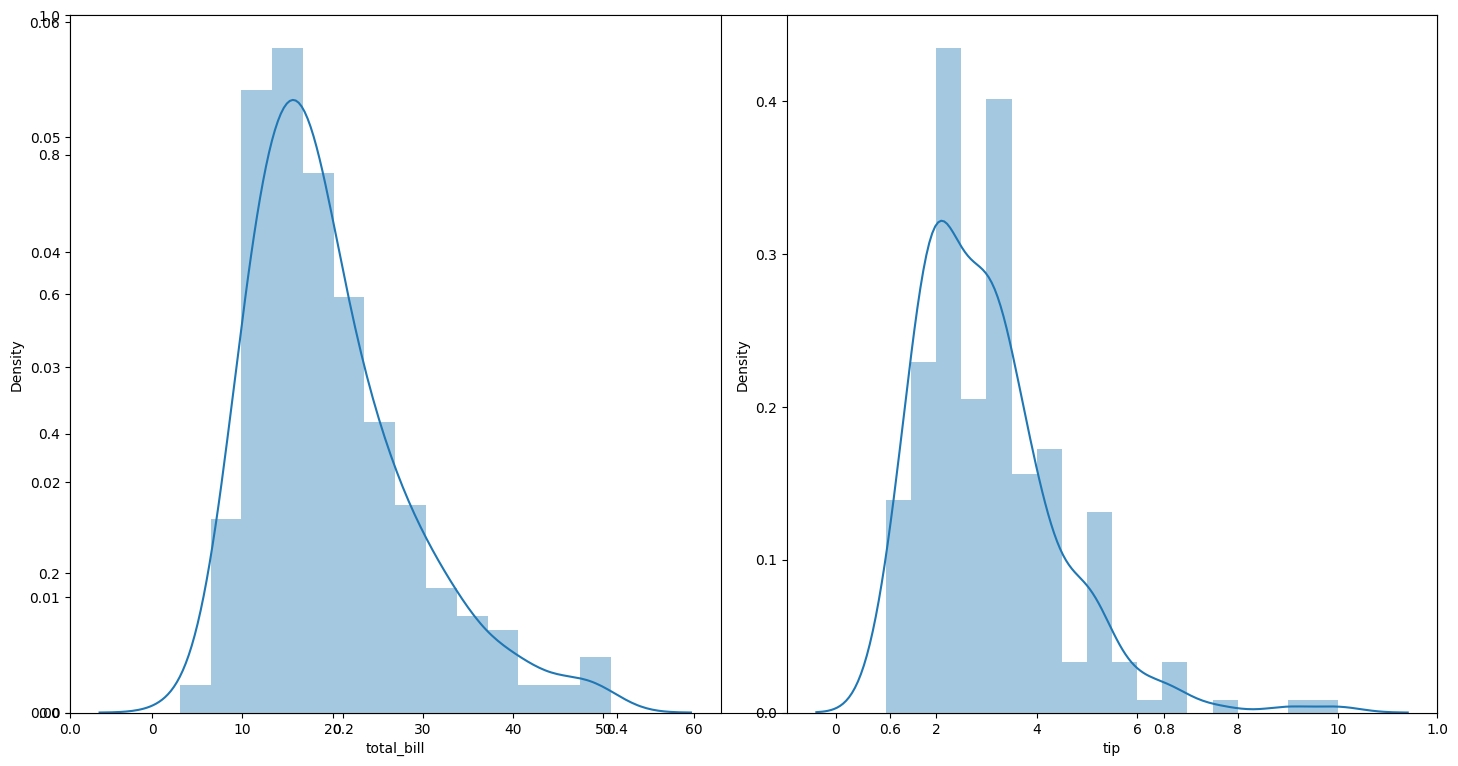

In [91]:
plt.subplots(figsize=(15,8))

for i, col in enumerate(['total_bill', 'tip']):
  plt.subplot(1,2, i + 1)
  sns.distplot(df[col])
plt.tight_layout()
plt.show()

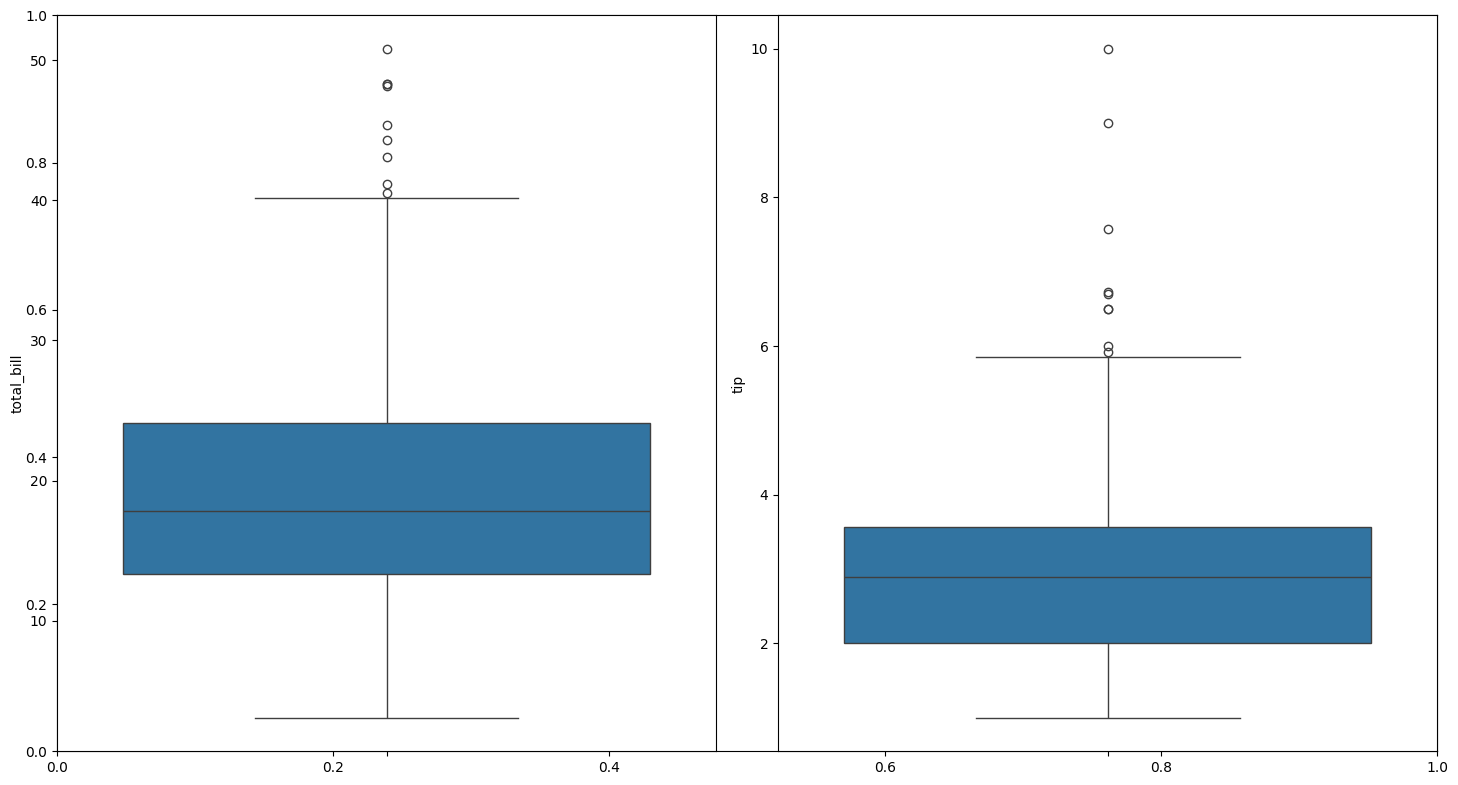

In [93]:
plt.subplots(figsize=(15,8))

for i, col in enumerate(['total_bill', 'tip']):
  plt.subplot(1,2, i + 1)
  sns.boxplot(df[col])
plt.tight_layout()
plt.show()

In [94]:
df.shape, df[(df['total_bill']<45) & (df['tip']<7)].shape

((244, 7), (238, 7))

In [95]:
df = df[(df['total_bill']<45) & (df['tip']<7)]

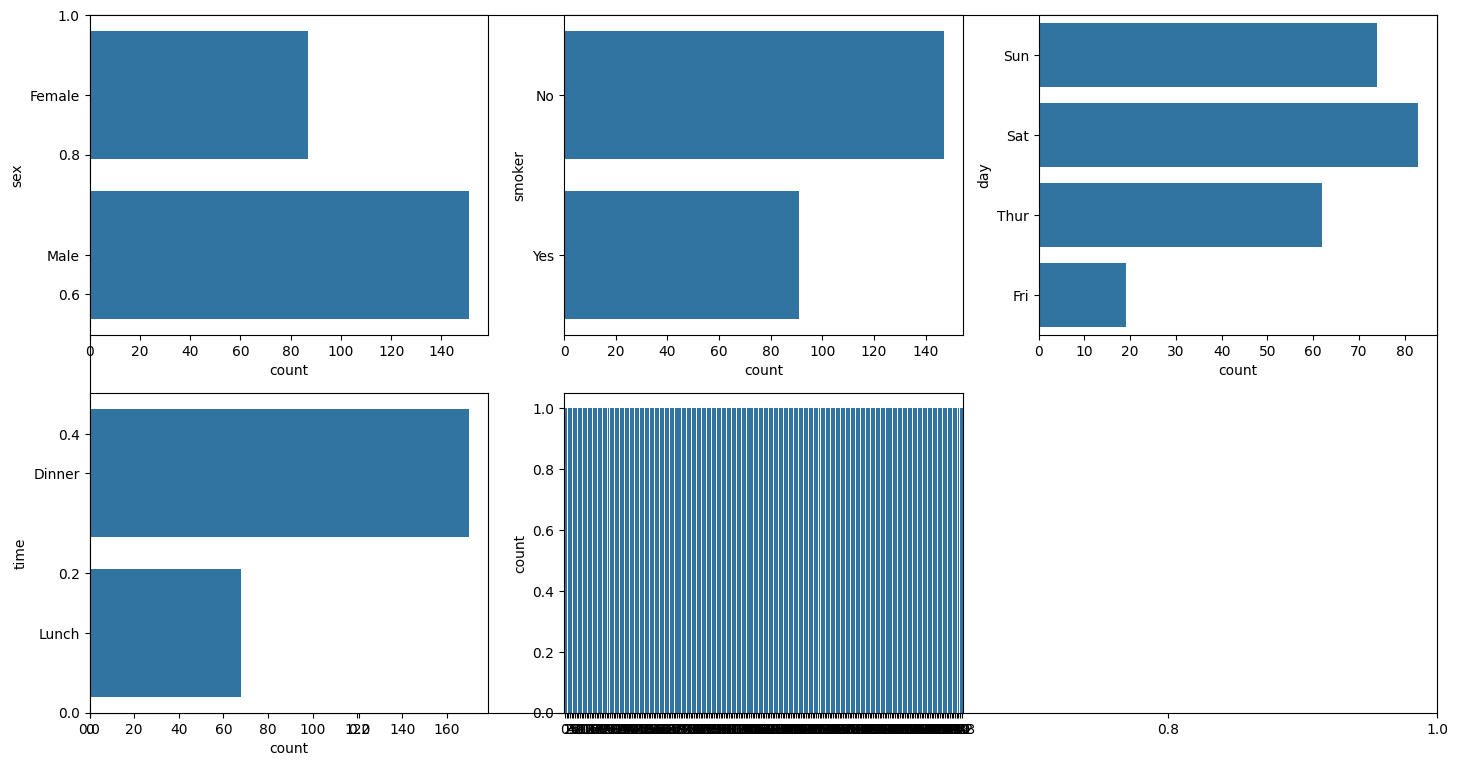

In [97]:
feat = df.loc[:,'sex':'size'].columns

plt.subplots(figsize=(15,8))
for i, col in enumerate(feat):
  plt.subplot(2,3, i + 1)
  sns.countplot(df[col])
plt.tight_layout()
plt.show()

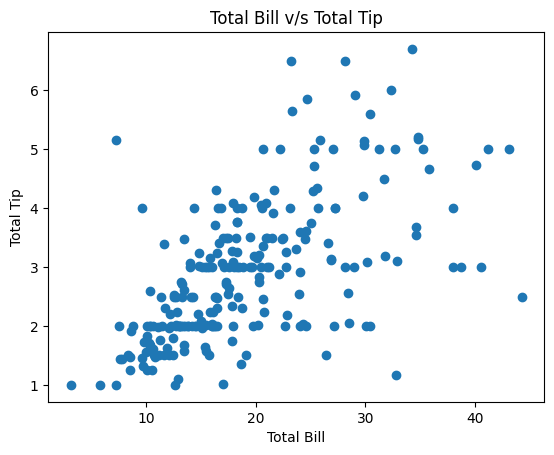

In [98]:
plt.scatter(df['total_bill'], df['tip'])
plt.title('Total Bill v/s Total Tip')
plt.xlabel('Total Bill')
plt.ylabel('Total Tip')
plt.show()

In [ ]:
df.groupby(['size']).mean(numeric_only=True)

,total_bill,tip
size,,
1,7.242500,1.437500
2,16.448013,2.582308
3,21.899722,3.206667
4,27.137647,3.814706
5,30.068000,4.028000
6,30.383333,5.300000


In [100]:
df.groupby(['time']).mean(numeric_only=True)

,total_bill,tip,size
time,,,
Dinner,19.882059,2.966235,2.582353
Lunch,17.168676,2.728088,2.411765


In [101]:
df.groupby(['day']).mean(numeric_only=True)

,total_bill,tip,size
day,,,
Fri,17.151579,2.734737,2.105263
Sat,19.175542,2.736024,2.457831
Sun,20.724865,3.228243,2.797297
Thur,17.682742,2.771452,2.451613


In [103]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
  if df[col].dtype == object:
    df[col] = le.fit_transform(df[col])

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,0,0,2,0,2
1,10.34,1.66,1,0,2,0,3
2,21.01,3.50,1,0,2,0,3
3,23.68,3.31,1,0,2,0,2
4,24.59,3.61,0,0,2,0,4


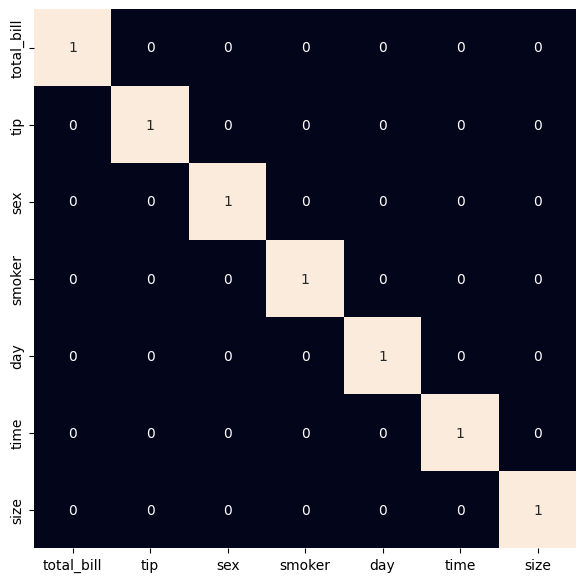

In [104]:
plt.figure(figsize=(7,7))
sns.heatmap(df.corr() > 0.7, annot = True, cbar = False)
plt.show()

In [105]:
from sklearn.model_selection import train_test_split

features = df.drop('tip', axis=1)
target = df['tip']

X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size=0.2, random_state=22)
X_train.shape, X_val.shape

((190, 6), (48, 6))

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

### 4. Build and Fit Models

In [107]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

models = [LinearRegression(), XGBRegressor(), RandomForestRegressor(), AdaBoostRegressor()]

for i in range(4):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')
  pred_train = models[i].predict(X_train)
  print('Training Accuracy : ', mae(Y_train, pred_train))

  pred_val = models[i].predict(X_val)
  print('Validation Accuracy : ', mae(Y_val, pred_val))
  print()

LinearRegression() : 
Training Accuracy :  0.6866406322422778
Validation Accuracy :  0.7903774704017295

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  0.02728007923929315
Validation Accuracy :  0.7682166453202566

RandomForestRegressor() : 
Training Accuracy :  0.28488842

### 5. Make Prediction

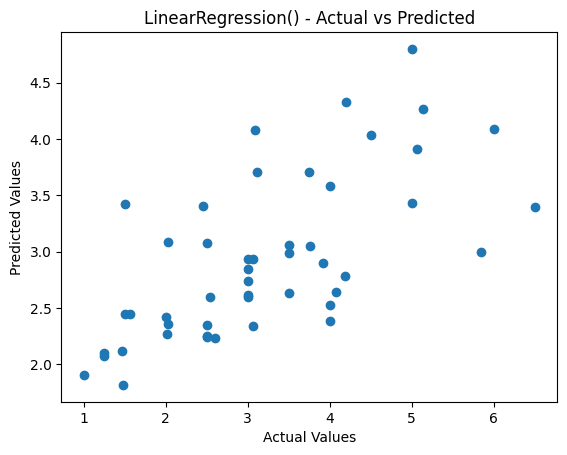

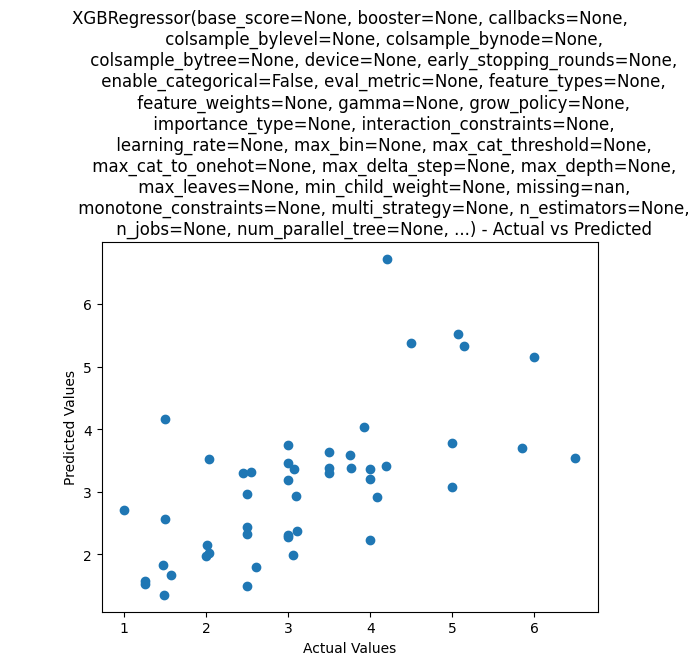

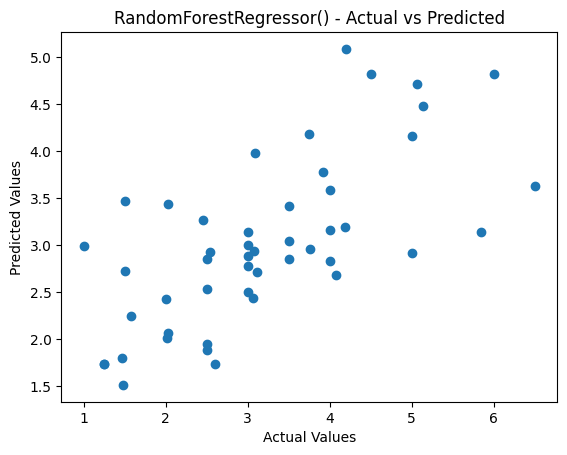

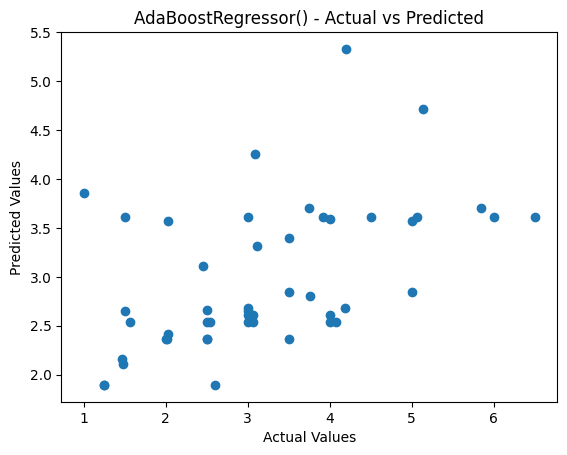

In [111]:
for model in models:
    y_pred = model.predict(X_val)

    plt.figure()
    plt.scatter(Y_val, y_pred)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{model} - Actual vs Predicted")
    plt.show()

### 6. Evaluate the Models

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for model in models:
    print(f'{model} :')

    # Predictions
    y_pred = model.predict(X_val)

    # Metrics
    mae_val = mean_absolute_error(Y_val, y_pred)
    mse_val = mean_squared_error(Y_val, y_pred)
    r2_val = r2_score(Y_val, y_pred)

    print("MAE:", mae_val)
    print("MSE:", mse_val)
    print("R2 Score:", r2_val)
    print()

    # Store results
    results.append((str(model), mae_val, mse_val, r2_val))

LinearRegression() :
MAE: 0.7903774704017295
MSE: 1.072464926613776
R2 Score: 0.3817424579483124

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...) :
MAE: 0.7682166453202566
MSE: 1.116482938407864
R2 Score: 0.356366832972172

RandomForestRegressor() :
MAE: 0.7291687499999996
MSE: 0.9746358806249994


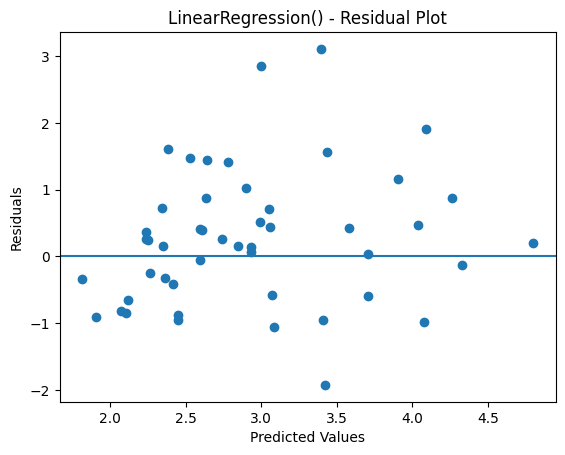

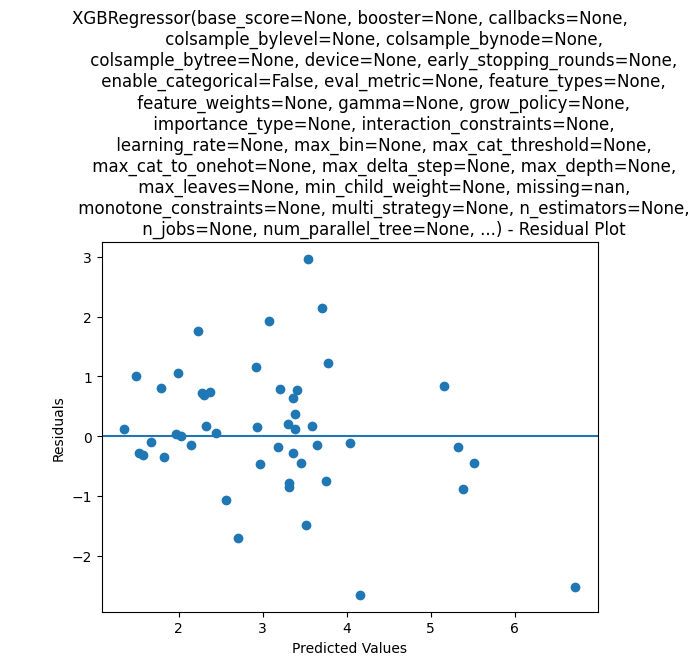

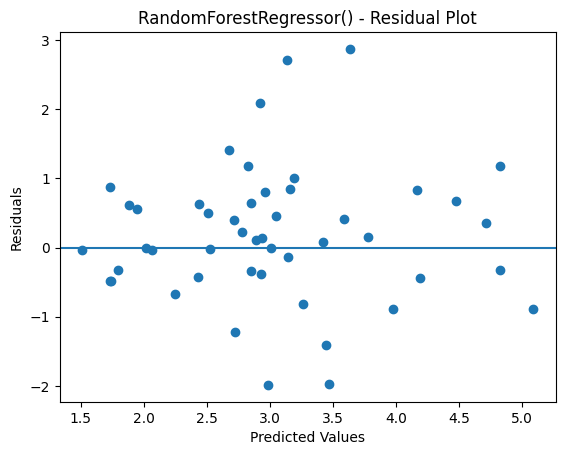

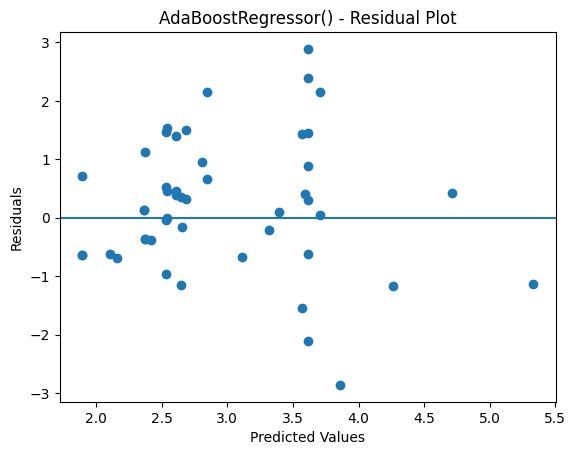

In [113]:
for model in models:
    y_pred = model.predict(X_val)
    residuals = Y_val - y_pred

    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.axhline(y=0)
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"{model} - Residual Plot")
    plt.show()

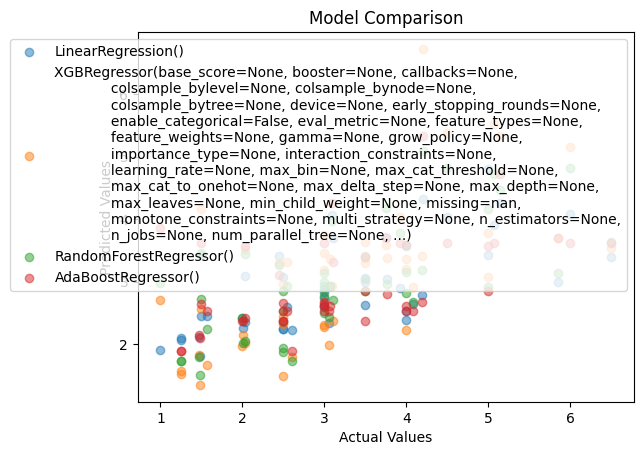

In [114]:
plt.figure()

for model in models:
    y_pred = model.predict(X_val)
    plt.scatter(Y_val, y_pred, label=str(model), alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Model Comparison")
plt.legend()
plt.show()

In [116]:
df_results = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2"])
df_results.sort_values(by="MAE")

,Model,MAE,MSE,R2
2,RandomForestRegressor(),0.729169,0.974636,0.438139
1,"XGBRegressor(base_score=None, booster=None, ca...",0.768217,1.116483,0.356367
0,LinearRegression(),0.790377,1.072465,0.381742
3,AdaBoostRegressor(),0.897816,1.345385,0.224409
